In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine

from pathlib import Path

# Project root — adjust once, use everywhere
BASE_DIR = Path(r"D:\code\mf-analysis")

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
DB_PATH = BASE_DIR / "data" / "db" / "bluestockmf.db"
REPORTS_DIR = BASE_DIR / "reports"

sns.set_style("whitegrid")
engine = create_engine(f"sqlite:///{DB_PATH}")

fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
dim_date = pd.read_sql("SELECT * FROM dim_date", engine, parse_dates=["full_date"])
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
nav = nav.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")
nav = nav.merge(fund_master[["amfi_code","scheme_name","fund_house","category"]], on="amfi_code", how="left")

In [2]:
nav = nav.sort_values(["amfi_code","full_date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
print(nav["daily_return"].describe())

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


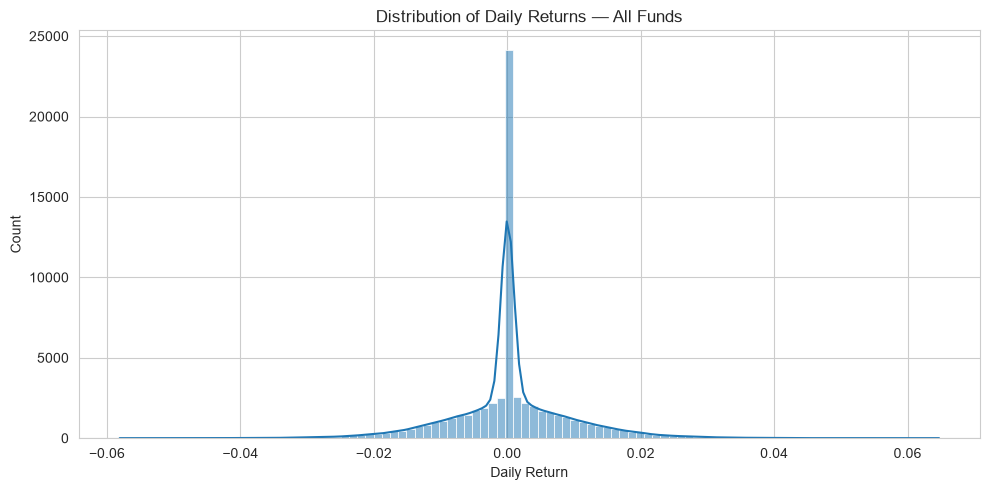

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(nav["daily_return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns — All Funds")
plt.xlabel("Daily Return")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "d4_01_daily_return_distribution.png", dpi=150)
plt.show()

In [4]:
def calculate_cagr(df, years):
    cutoff_date = df["full_date"].max() - pd.DateOffset(years=years)
    period_df = df[df["full_date"] >= cutoff_date].sort_values("full_date")
    
    if len(period_df) < 2:
        return np.nan
    
    nav_start = period_df["nav"].iloc[0]
    nav_end = period_df["nav"].iloc[-1]
    n_years = (period_df["full_date"].iloc[-1] - period_df["full_date"].iloc[0]).days / 365.25
    
    if n_years == 0 or nav_start <= 0:
        return np.nan
    
    cagr = (nav_end / nav_start) ** (1/n_years) - 1
    return cagr * 100

In [5]:
cagr_results = []
for code in fund_master["amfi_code"]:
    fund_nav = nav[nav["amfi_code"] == code]
    cagr_results.append({
        "amfi_code": code,
        "scheme_name": fund_nav["scheme_name"].iloc[0] if len(fund_nav) > 0 else None,
        "cagr_1yr": calculate_cagr(fund_nav, 1),
        "cagr_3yr": calculate_cagr(fund_nav, 3),
        "cagr_5yr": calculate_cagr(fund_nav, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
print(cagr_df.head(10))
cagr_df.to_csv(REPORTS_DIR / "cagr_report.csv", index=False)

   amfi_code                                        scheme_name   cagr_1yr  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth  -2.225777   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   3.707553   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  53.277195   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  47.963794   
4     101207             ABSL Small Cap Fund - Regular - Growth -24.000309   
5     101208                ABSL Liquid Fund - Regular - Growth   7.241777   
6     102885         UTI Nifty 50 Index Fund - Regular - Growth  20.222859   
7     102886                UTI Mid Cap Fund - Regular - Growth -16.807960   
8     102887              UTI Flexi Cap Fund - Regular - Growth  13.593044   
9     118632     Nippon India Large Cap Fund - Regular - Growth  34.007896   

    cagr_3yr   cagr_5yr  
0   1.292353   2.637074  
1   3.915479   4.458210  
2  32.433971  30.123153  
3  28.960211  23.538361  
4  -4.15145

In [6]:
def calculate_sharpe(returns, risk_free_annual=0.065):
    returns = returns.dropna()
    if len(returns) < 2 or returns.std() == 0:
        return np.nan
    
    mean_daily_return = returns.mean()
    std_daily_return = returns.std()
    
    rf_daily = risk_free_annual / 252
    
    sharpe = (mean_daily_return - rf_daily) / std_daily_return
    sharpe_annualized = sharpe * np.sqrt(252)
    return sharpe_annualized

In [7]:
sharpe_results = []
for code in fund_master["amfi_code"]:
    fund_returns = nav[nav["amfi_code"] == code]["daily_return"]
    scheme_name = fund_master[fund_master["amfi_code"]==code]["scheme_name"].iloc[0]
    sharpe_results.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "sharpe_ratio": calculate_sharpe(fund_returns)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)
print(sharpe_df.head(10))
sharpe_df.to_csv(REPORTS_DIR / "sharpe_values.csv", index=False)

    amfi_code                                        scheme_name  sharpe_ratio
34     148567      Mirae Asset Large Cap Fund - Regular - Growth      1.068224
30     120843             Kotak Flexicap Fund - Regular - Growth      0.965561
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth      0.919047
25     120505           ICICI Pru Midcap Fund - Regular - Growth      0.883256
19     119551          SBI Bluechip Fund - Regular Plan - Growth      0.860977
38     149323                 DSP Midcap Fund - Regular - Growth      0.832885
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      0.808268
9      118632     Nippon India Large Cap Fund - Regular - Growth      0.758851
16     119094                Axis Midcap Fund - Regular - Growth      0.730547
3      101206      ABSL Frontline Equity Fund - Regular - Growth      0.717409


In [8]:
def calculate_sortino(returns, risk_free_annual=0.065):
    returns = returns.dropna()
    if len(returns) < 2:
        return np.nan
    
    mean_daily_return = returns.mean()
    rf_daily = risk_free_annual / 252
    
    downside_returns = returns[returns < 0]
    if len(downside_returns) == 0 or downside_returns.std() == 0:
        return np.nan
    
    downside_std = downside_returns.std()
    
    sortino = (mean_daily_return - rf_daily) / downside_std
    sortino_annualized = sortino * np.sqrt(252)
    return sortino_annualized

In [9]:
sortino_results = []
for code in fund_master["amfi_code"]:
    fund_returns = nav[nav["amfi_code"] == code]["daily_return"]
    scheme_name = fund_master[fund_master["amfi_code"]==code]["scheme_name"].iloc[0]
    sortino_results.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "sortino_ratio": calculate_sortino(fund_returns)
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)
print(sortino_df.head(10))
sortino_df.to_csv(REPORTS_DIR / "sortino_values.csv", index=False)

    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
21     119598         SBI Small Cap Fund - Regular Plan - Growth   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   

    sortino_ratio  
34       1.490739  
30       1.479503  
36       1.352815  
19       1.291483  
25       1.285843  
38       1.167793  
2        1.144216  
9        1.098880  
21       1.067256  
24       1.063964  


In [10]:
benchmark = pd.read_csv(DATA_RAW / "10_benchmark_indices.csv")
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [11]:
print(benchmark["index_name"].unique())


<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [12]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [13]:
def calculate_alpha_beta(fund_code, nav_df, benchmark_df):
    fund_returns = nav_df[nav_df["amfi_code"] == fund_code][["full_date", "daily_return"]]
    merged = fund_returns.merge(benchmark_df[["date","benchmark_return"]], 
                                  left_on="full_date", right_on="date", how="inner")
    merged = merged.dropna()
    
    if len(merged) < 30:  # need reasonable sample size for a meaningful regression
        return np.nan, np.nan
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["benchmark_return"], merged["daily_return"])
    
    beta = slope
    alpha = intercept * 252  # annualize the daily intercept
    return alpha * 100, beta  # alpha as percentage

In [14]:
alpha_beta_results = []
for code in fund_master["amfi_code"]:
    scheme_name = fund_master[fund_master["amfi_code"]==code]["scheme_name"].iloc[0]
    alpha, beta = calculate_alpha_beta(code, nav, nifty100)
    alpha_beta_results.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "alpha_pct": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df.head(10))
alpha_beta_df.to_csv(REPORTS_DIR / "alpha_beta.csv", index=False)

   amfi_code                                        scheme_name  alpha_pct  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   3.747581   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   4.281792   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  27.195355   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  21.399785   
4     101207             ABSL Small Cap Fund - Regular - Growth  10.897092   
5     101208                ABSL Liquid Fund - Regular - Growth   6.086146   
6     102885         UTI Nifty 50 Index Fund - Regular - Growth  17.048757   
7     102886                UTI Mid Cap Fund - Regular - Growth   2.896940   
8     102887              UTI Flexi Cap Fund - Regular - Growth  16.211257   
9     118632     Nippon India Large Cap Fund - Regular - Growth  21.829398   

       beta  
0 -0.058268  
1  0.001158  
2  0.005104  
3  0.021086  
4 -0.065289  
5  0.000267  
6 -0.019487  
7 -0.042125  
8  0.016683  
9

In [15]:
# Check sample sizes and date ranges for both
print("NAV date range:", nav["full_date"].min(), "to", nav["full_date"].max())
print("Nifty100 date range:", nifty100["date"].min(), "to", nifty100["date"].max())

# Check a single fund's merge directly
test_code = fund_master["amfi_code"].iloc[0]
fund_returns = nav[nav["amfi_code"] == test_code][["full_date", "daily_return"]]
print("\nFund returns sample:")
print(fund_returns.head())

merged_test = fund_returns.merge(nifty100[["date","benchmark_return"]], 
                                   left_on="full_date", right_on="date", how="inner")
print("\nMerged rows:", len(merged_test))
print(merged_test.head(10))

NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Nifty100 date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Fund returns sample:
   full_date  daily_return
0 2022-01-03           NaN
1 2022-01-04     -0.010306
2 2022-01-05      0.012865
3 2022-01-06     -0.011377
4 2022-01-07     -0.001210

Merged rows: 1150
   full_date  daily_return       date  benchmark_return
0 2022-01-03           NaN 2022-01-03               NaN
1 2022-01-04     -0.010306 2022-01-04         -0.013540
2 2022-01-05      0.012865 2022-01-05          0.004003
3 2022-01-06     -0.011377 2022-01-06         -0.002935
4 2022-01-07     -0.001210 2022-01-07          0.006150
5 2022-01-10     -0.008639 2022-01-10         -0.008351
6 2022-01-11      0.005562 2022-01-11          0.004942
7 2022-01-12     -0.002404 2022-01-12          0.009128
8 2022-01-13     -0.004050 2022-01-13          0.003746
9 2022-01-14      0.008073 2022-01-14         -0.014098


In [16]:
test_merged = merged_test.dropna()
print("Rows after dropna:", len(test_merged))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    test_merged["benchmark_return"], test_merged["daily_return"])

print("Slope (beta):", slope)
print("Intercept (daily alpha):", intercept)
print("R-value:", r_value)
print("R-squared:", r_value**2)

Rows after dropna: 1149
Slope (beta): -0.05826843143880891
Intercept (daily alpha): 0.00014871352235886037
R-value: -0.05162395469288772
R-squared: 0.002665032698133324


In [17]:
nifty_index_fund = fund_master[fund_master["scheme_name"].str.contains("Nifty 50 Index", case=False, na=False)]
print(nifty_index_fund)

idx_code = nifty_index_fund["amfi_code"].iloc[0]
idx_returns = nav[nav["amfi_code"] == idx_code][["full_date", "daily_return"]]
idx_merged = idx_returns.merge(nifty100[["date","benchmark_return"]], 
                                  left_on="full_date", right_on="date", how="inner").dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    idx_merged["benchmark_return"], idx_merged["daily_return"])
print("Index fund beta:", slope, "| R-squared:", r_value**2)

   amfi_code                                 scheme_name       fund_house  \
6     102885  UTI Nifty 50 Index Fund - Regular - Growth  UTI Mutual Fund   

  category sub_category  plan risk_category sebi_category_code  
6    Index         None  None          None               None  
Index fund beta: -0.019486785689474546 | R-squared: 0.00038285030730923926


In [18]:
def calculate_max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1
    max_dd = drawdown.min()
    max_dd_date_idx = drawdown.idxmin()
    return max_dd * 100, max_dd_date_idx

In [19]:
drawdown_results = []
for code in fund_master["amfi_code"]:
    fund_nav = nav[nav["amfi_code"] == code].sort_values("full_date").reset_index(drop=True)
    scheme_name = fund_nav["scheme_name"].iloc[0]
    
    max_dd, dd_idx = calculate_max_drawdown(fund_nav["nav"])
    worst_date = fund_nav.loc[dd_idx, "full_date"]
    
    # Find the peak date before the worst drawdown
    running_max = fund_nav["nav"].cummax()
    peak_value = running_max.loc[dd_idx]
    peak_date = fund_nav[fund_nav["nav"] == peak_value]["full_date"].iloc[0]
    
    drawdown_results.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "max_drawdown_pct": max_dd,
        "peak_date": peak_date,
        "trough_date": worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.sort_values("max_drawdown_pct")
print(drawdown_df.head(10))
drawdown_df.to_csv(REPORTS_DIR / "max_drawdown.csv", index=False)

    amfi_code                                     scheme_name  \
22     119599       SBI Small Cap Fund - Direct Plan - Growth   
17     119095          Axis Small Cap Fund - Regular - Growth   
4      101207          ABSL Small Cap Fund - Regular - Growth   
39     149324           DSP Small Cap Fund - Regular - Growth   
21     119598      SBI Small Cap Fund - Regular Plan - Growth   
7      102886             UTI Mid Cap Fund - Regular - Growth   
0      100016       HDFC Top 100 Fund - Regular Plan - Growth   
29     120842   Kotak Emerging Equity Fund - Regular - Growth   
11     118634  Nippon India Small Cap Fund - Regular - Growth   
15     119093            Axis Bluechip Fund - Direct - Growth   

    max_drawdown_pct  peak_date trough_date  
22        -52.574221 2023-01-17  2025-10-28  
17        -51.677754 2025-05-22  2026-05-11  
4         -35.446916 2024-11-21  2026-05-11  
39        -31.171900 2024-05-03  2025-01-03  
21        -28.706006 2024-08-28  2025-05-14  
7       

In [20]:
scorecard = fund_master[["amfi_code","scheme_name","fund_house","category"]].copy()

scorecard = scorecard.merge(cagr_df[["amfi_code","cagr_3yr"]], on="amfi_code", how="left")
scorecard = scorecard.merge(sharpe_df[["amfi_code","sharpe_ratio"]], on="amfi_code", how="left")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code","alpha_pct"]], on="amfi_code", how="left")
scorecard = scorecard.merge(drawdown_df[["amfi_code","max_drawdown_pct"]], on="amfi_code", how="left")

expense_data = pd.read_csv(DATA_RAW / "01_fund_master.csv")[["amfi_code","expense_ratio_pct"]]
scorecard = scorecard.merge(expense_data, on="amfi_code", how="left")

print(scorecard.head())

   amfi_code                                        scheme_name  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   
4     101207             ABSL Small Cap Fund - Regular - Growth   

                 fund_house        category   cagr_3yr  sharpe_ratio  \
0          HDFC Mutual Fund       Large Cap   1.292353     -0.321019   
1          HDFC Mutual Fund  Short Duration   3.915479     -1.039941   
2          HDFC Mutual Fund         Mid Cap  32.433971      0.808268   
3  Aditya Birla Sun Life MF       Large Cap  28.960211      0.717409   
4  Aditya Birla Sun Life MF       Small Cap  -4.151454      0.052618   

   alpha_pct  max_drawdown_pct  expense_ratio_pct  
0   3.747581        -24.734441               1.55  
1   4.281792         -4.308264               0.56  
2  27.19

In [21]:
test_df = pd.DataFrame({"expense_ratio_pct": [0.5, 1.0, 1.5, 2.0]})
test_df["rank_test"] = test_df["expense_ratio_pct"].rank(ascending=False, pct=True) * 100
print(test_df)

   expense_ratio_pct  rank_test
0                0.5      100.0
1                1.0       75.0
2                1.5       50.0
3                2.0       25.0


In [22]:
scorecard["rank_return"] = scorecard["cagr_3yr"].rank(ascending=False, pct=True) * 100
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False, pct=True) * 100
scorecard["rank_alpha"] = scorecard["alpha_pct"].rank(ascending=False, pct=True) * 100
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=False, pct=True) * 100
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].rank(ascending=True, pct=True) * 100

In [23]:
scorecard["fund_score"] = (
    0.30 * scorecard["rank_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_maxdd"]
)

In [24]:
scorecard = scorecard.sort_values("fund_score", ascending=False)
scorecard_final = scorecard[["amfi_code","scheme_name","fund_house","category",
                               "cagr_3yr","sharpe_ratio","alpha_pct","expense_ratio_pct",
                               "max_drawdown_pct","fund_score"]]

print(scorecard_final.head(10))
scorecard_final.to_csv(REPORTS_DIR / "fund_scorecard.csv", index=False)

    amfi_code                                        scheme_name  \
1      100025       HDFC Short Term Debt Fund - Regular - Growth   
13     118636  Nippon India Gilt Securities Fund - Regular - ...   
31     120844               Kotak Liquid Fund - Regular - Growth   
5      101208                ABSL Liquid Fund - Regular - Growth   
18     119120       SBI Magnum Gilt Fund - Regular Plan - Growth   
27     120507           ICICI Pru Liquid Fund - Regular - Growth   
22     119599          SBI Small Cap Fund - Direct Plan - Growth   
17     119095             Axis Small Cap Fund - Regular - Growth   
7      102886                UTI Mid Cap Fund - Regular - Growth   
0      100016          HDFC Top 100 Fund - Regular Plan - Growth   

                  fund_house        category   cagr_3yr  sharpe_ratio  \
1           HDFC Mutual Fund  Short Duration   3.915479     -1.039941   
13           Nippon India MF            Gilt   4.061260     -0.850579   
31         Kotak Mahindra MF    

In [25]:
scorecard_final.to_csv(REPORTS_DIR / "fund_scorecard.csv", index=False)
print("Saved fund_scorecard.csv with", len(scorecard_final), "funds")

Saved fund_scorecard.csv with 40 funds


In [26]:
top5_codes = scorecard_final.head(5)["amfi_code"].tolist()
top5_names = scorecard_final.head(5)["scheme_name"].tolist()
print(top5_codes, top5_names)

[100025, 118636, 120844, 101208, 119120] ['HDFC Short Term Debt Fund - Regular - Growth', 'Nippon India Gilt Securities Fund - Regular - Growth', 'Kotak Liquid Fund - Regular - Growth', 'ABSL Liquid Fund - Regular - Growth', 'SBI Magnum Gilt Fund - Regular Plan - Growth']


In [27]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty50 = nifty50.sort_values("date")
nifty50["normalized"] = nifty50["close_value"] / nifty50["close_value"].iloc[0] * 100

nifty100_norm = nifty100.copy()
nifty100_norm["normalized"] = nifty100_norm["close_value"] / nifty100_norm["close_value"].iloc[0] * 100

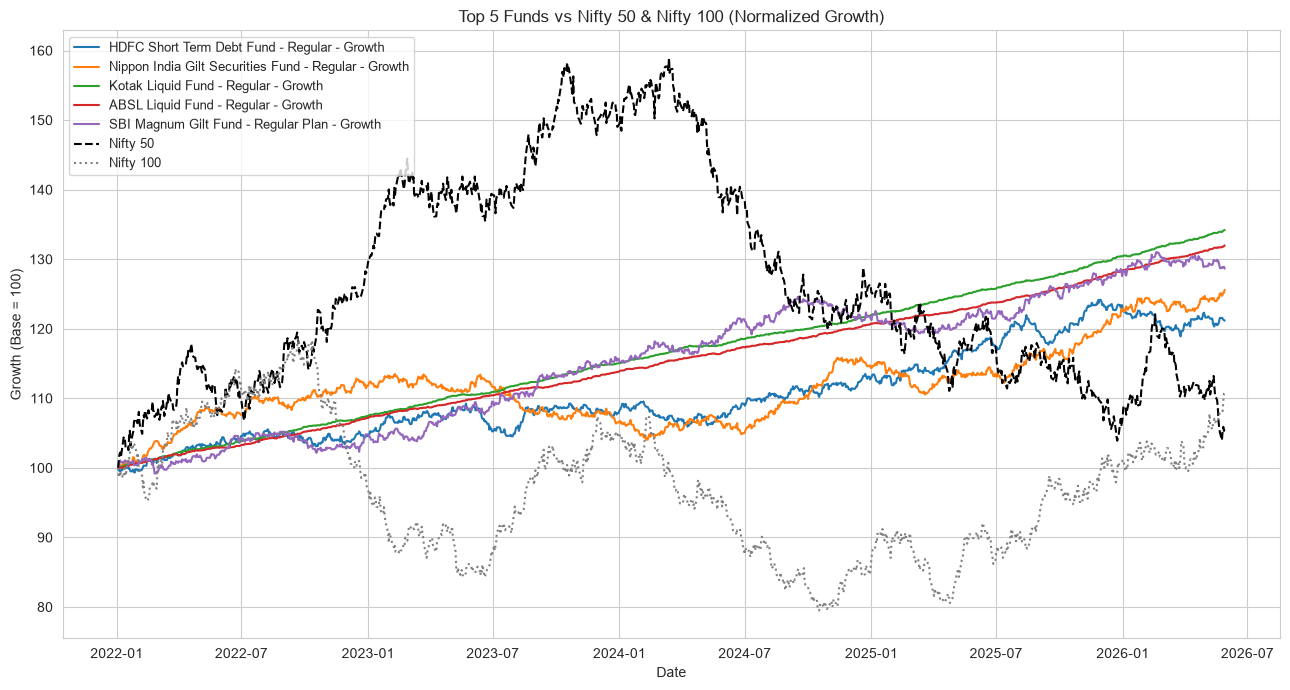

In [28]:
plt.figure(figsize=(13,7))

for code, name in zip(top5_codes, top5_names):
    fund_nav = nav[nav["amfi_code"] == code].sort_values("full_date")
    fund_nav_norm = fund_nav["nav"] / fund_nav["nav"].iloc[0] * 100
    plt.plot(fund_nav["full_date"], fund_nav_norm, label=name)

plt.plot(nifty50["date"], nifty50["normalized"], label="Nifty 50", 
          linestyle="--", color="black", linewidth=1.5)
plt.plot(nifty100_norm["date"], nifty100_norm["normalized"], label="Nifty 100", 
          linestyle=":", color="gray", linewidth=1.5)

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100 (Normalized Growth)")
plt.ylabel("Growth (Base = 100)")
plt.xlabel("Date")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "08_benchmark_comparison.png", dpi=150)
plt.show()

In [29]:
def tracking_error(fund_code, benchmark_df):
    fund_returns = nav[nav["amfi_code"]==fund_code][["full_date","daily_return"]]
    merged = fund_returns.merge(benchmark_df[["date","benchmark_return"]], 
                                  left_on="full_date", right_on="date", how="inner").dropna()
    diff = merged["daily_return"] - merged["benchmark_return"]
    te = diff.std() * np.sqrt(252) * 100
    return te

for code, name in zip(top5_codes, top5_names):
    te = tracking_error(code, nifty100)
    print(f"{name}: Tracking Error = {te:.2f}%")

HDFC Short Term Debt Fund - Regular - Growth: Tracking Error = 13.45%
Nippon India Gilt Securities Fund - Regular - Growth: Tracking Error = 13.48%
Kotak Liquid Fund - Regular - Growth: Tracking Error = 12.90%
ABSL Liquid Fund - Regular - Growth: Tracking Error = 12.90%
SBI Magnum Gilt Fund - Regular Plan - Growth: Tracking Error = 13.56%


In [30]:
original_perf = pd.read_sql("SELECT amfi_code, alpha, beta, sharpe_ratio FROM fact_performance", engine)
fund_master = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund", engine)

original_perf = original_perf.merge(fund_master, on="amfi_code")
print(original_perf[original_perf["scheme_name"].str.contains("Nifty 50 Index", case=False, na=False)])
print(original_perf.describe())

    amfi_code  alpha  beta  sharpe_ratio  \
31     102885   0.93   0.9          0.93   

                                   scheme_name  
31  UTI Nifty 50 Index Fund - Regular - Growth  
           amfi_code      alpha       beta  sharpe_ratio
count      40.000000  40.000000  40.000000     40.000000
mean   120247.000000   1.253500   0.873250      1.361750
std     14534.998667   0.447412   0.224846      1.475805
min    100016.000000   0.510000   0.220000      0.800000
25%    118632.750000   0.887500   0.890000      0.865000
50%    119551.500000   1.205000   0.960000      0.925000
75%    120842.250000   1.700000   1.000000      0.985000
max    149324.000000   1.980000   1.040000      7.680000


In [31]:
print("Fund daily_return sample stats:")
print(nav["daily_return"].describe())

print("\nBenchmark daily_return sample stats:")
print(nifty100["benchmark_return"].describe())

Fund daily_return sample stats:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Benchmark daily_return sample stats:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [32]:
test_code = fund_master["amfi_code"].iloc[0]
fund_check = nav[nav["amfi_code"] == test_code][["full_date","daily_return"]].head(20)
bench_check = nifty100[["date","benchmark_return"]].head(20)

print("Fund dates:")
print(fund_check)
print("\nBenchmark dates:")
print(bench_check)

Fund dates:
    full_date  daily_return
0  2022-01-03           NaN
1  2022-01-04     -0.010306
2  2022-01-05      0.012865
3  2022-01-06     -0.011377
4  2022-01-07     -0.001210
5  2022-01-08      0.000000
6  2022-01-09      0.000000
7  2022-01-10     -0.008639
8  2022-01-11      0.005562
9  2022-01-12     -0.002404
10 2022-01-13     -0.004050
11 2022-01-14      0.008073
12 2022-01-15      0.000000
13 2022-01-16      0.000000
14 2022-01-17      0.000776
15 2022-01-18      0.005085
16 2022-01-19     -0.008106
17 2022-01-20     -0.011803
18 2022-01-21      0.001462
19 2022-01-22      0.000000

Benchmark dates:
           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150
1155 2022-01-10         -0.008351
1156 2022-01-11          0.004942
1157 2022-01-12          0.009128
1158 2022-01-13          0.003746
1159 2022-01-14         -0.014098
1160 202

In [33]:
print(nifty100.columns.tolist())
print(nifty100[["date","close_value","benchmark_return"]].head(10))
print("Is nifty100 sorted?", nifty100["date"].is_monotonic_increasing)

['date', 'index_name', 'close_value', 'benchmark_return']
           date  close_value  benchmark_return
1150 2022-01-03     17778.24               NaN
1151 2022-01-04     17537.52         -0.013540
1152 2022-01-05     17607.73          0.004003
1153 2022-01-06     17556.05         -0.002935
1154 2022-01-07     17664.02          0.006150
1155 2022-01-10     17516.51         -0.008351
1156 2022-01-11     17603.08          0.004942
1157 2022-01-12     17763.76          0.009128
1158 2022-01-13     17830.30          0.003746
1159 2022-01-14     17578.93         -0.014098
Is nifty100 sorted? True


In [34]:
nav_trading_only = nav[nav["full_date"].dt.dayofweek < 5].copy()
nav_trading_only = nav_trading_only.sort_values(["amfi_code","full_date"])
nav_trading_only["daily_return"] = nav_trading_only.groupby("amfi_code")["nav"].pct_change()

print(nav_trading_only[nav_trading_only["amfi_code"]==test_code][["full_date","daily_return"]].head(15))

    full_date  daily_return
0  2022-01-03           NaN
1  2022-01-04     -0.010306
2  2022-01-05      0.012865
3  2022-01-06     -0.011377
4  2022-01-07     -0.001210
7  2022-01-10     -0.008639
8  2022-01-11      0.005562
9  2022-01-12     -0.002404
10 2022-01-13     -0.004050
11 2022-01-14      0.008073
14 2022-01-17      0.000776
15 2022-01-18      0.005085
16 2022-01-19     -0.008106
17 2022-01-20     -0.011803
18 2022-01-21      0.001462


In [35]:
idx_returns_fixed = nav_trading_only[nav_trading_only["amfi_code"] == idx_code][["full_date","daily_return"]]
idx_merged_fixed = idx_returns_fixed.merge(nifty100[["date","benchmark_return"]], 
                                              left_on="full_date", right_on="date", how="inner").dropna()

print("Merged rows:", len(idx_merged_fixed))

from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    idx_merged_fixed["benchmark_return"], idx_merged_fixed["daily_return"])
print("Fixed index fund beta:", slope, "| R-squared:", r_value**2)

Merged rows: 1149
Fixed index fund beta: -0.019486785689474546 | R-squared: 0.00038285030730923926


In [36]:
print(idx_merged_fixed[["full_date","daily_return","benchmark_return"]].head(20))
print("\nCorrelation (pandas built-in):", idx_merged_fixed["daily_return"].corr(idx_merged_fixed["benchmark_return"]))

    full_date  daily_return  benchmark_return
1  2022-01-04      0.011122         -0.013540
2  2022-01-05     -0.007878          0.004003
3  2022-01-06      0.015277         -0.002935
4  2022-01-07     -0.009369          0.006150
5  2022-01-10     -0.001202         -0.008351
6  2022-01-11      0.011263          0.004942
7  2022-01-12      0.004676          0.009128
8  2022-01-13     -0.009585          0.003746
9  2022-01-14      0.009862         -0.014098
10 2022-01-17      0.003305          0.020825
11 2022-01-18     -0.002888          0.005362
12 2022-01-19     -0.012040         -0.001481
13 2022-01-20      0.004085          0.005597
14 2022-01-21     -0.000822          0.017932
15 2022-01-24      0.001797         -0.011037
16 2022-01-25     -0.012388          0.009472
17 2022-01-26     -0.002908         -0.000886
18 2022-01-27      0.004459         -0.002120
19 2022-01-28      0.016009         -0.001632
20 2022-01-31     -0.001165         -0.016514

Correlation (pandas built-in): -0

In [37]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty50 = nifty50.sort_values("date")
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

idx_merged_n50 = idx_returns_fixed.merge(nifty50[["date","benchmark_return"]], 
                                            left_on="full_date", right_on="date", how="inner").dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    idx_merged_n50["benchmark_return"], idx_merged_n50["daily_return"])
print("Index fund vs NIFTY50 — Beta:", slope, "| R-squared:", r_value**2)

Index fund vs NIFTY50 — Beta: -0.0018841874054637147 | R-squared: 3.567128117836139e-06


In [38]:
print("Rows for index fund in nav:", len(nav[nav["amfi_code"]==idx_code]))
print("Unique dates for index fund:", nav[nav["amfi_code"]==idx_code]["full_date"].nunique())

Rows for index fund in nav: 1608
Unique dates for index fund: 1608


In [39]:
idx_raw = nav[nav["amfi_code"]==idx_code][["full_date","nav"]].sort_values("full_date")
print(idx_raw.head(20))
print("\nNAV stats:")
print(idx_raw["nav"].describe())

      full_date      nav
9648 2022-01-03  89.8728
9649 2022-01-04  90.8724
9650 2022-01-05  90.1565
9651 2022-01-06  91.5338
9652 2022-01-07  90.6762
9653 2022-01-08  90.6762
9654 2022-01-09  90.6762
9655 2022-01-10  90.5672
9656 2022-01-11  91.5873
9657 2022-01-12  92.0156
9658 2022-01-13  91.1336
9659 2022-01-14  92.0324
9660 2022-01-15  92.0324
9661 2022-01-16  92.0324
9662 2022-01-17  92.3366
9663 2022-01-18  92.0699
9664 2022-01-19  90.9614
9665 2022-01-20  91.3330
9666 2022-01-21  91.2579
9667 2022-01-22  91.2579

NAV stats:
count    1608.000000
mean      128.464688
std        28.624702
min        83.599900
25%       103.091175
50%       127.300050
75%       153.985800
max       187.929500
Name: nav, dtype: float64


In [40]:
idx_nav_first = idx_raw["nav"].iloc[0]
idx_nav_last = idx_raw["nav"].iloc[-1]
years = (idx_raw["full_date"].iloc[-1] - idx_raw["full_date"].iloc[0]).days / 365.25

computed_cagr = ((idx_nav_last/idx_nav_first) ** (1/years) - 1) * 100
print("Computed CAGR from raw NAV:", computed_cagr)

stated_return = pd.read_sql(f"SELECT return_1yr_pct, return_3yr_pct, return_5yr_pct FROM fact_performance WHERE amfi_code={idx_code}", engine)
print("fact_performance's stated returns:")
print(stated_return)

Computed CAGR from raw NAV: 18.23237888770595
fact_performance's stated returns:
   return_1yr_pct  return_3yr_pct  return_5yr_pct
0           13.76            12.1           11.31
